In [1]:
#se importan las librerias necesarias 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn
seaborn.set()

In [3]:
data = pd.read_csv('1.02. Multiple linear regression.csv')

In [4]:
data

,SAT,GPA,"Rand 1,2,3"
0,1714,2.40,1
1,1664,2.52,3
2,1760,2.54,3
3,1685,2.74,3
4,1693,2.83,2
...,...,...,...
79,1936,3.71,3
80,1810,3.71,1
81,1987,3.73,3
82,1962,3.76,1


Como puede ver en la imagen de arriba, tenemos datos sobre los resultados de SAT y GPA de los estudiantes. Sin embargo, hay una variable adicional, llamada Rand 1,2,3. Hemos generado una variable que asigna 1, 2 o 3 aleatoriamente a cada estudiante. Estamos 100% seguros de que esta variable no puede predecir el GPA universitario.

Entonces, este es nuestro modelo: el GPA de la universidad es igual a b0+ b1 * puntaje SAT +b2 * la variable aleatoria.

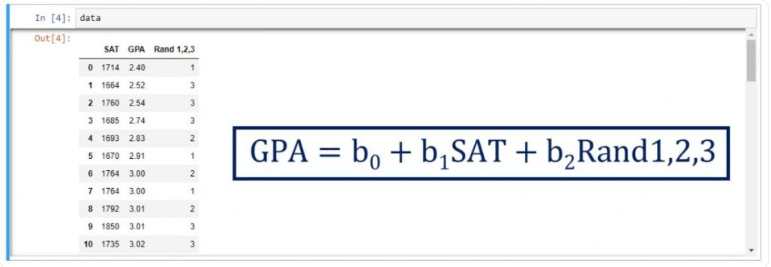

In [5]:
data.describe()

,SAT,GPA,"Rand 1,2,3"
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,2.059524
std,104.530661,0.271617,0.855192
min,1634.000000,2.400000,1.000000
25%,1772.000000,3.190000,1.000000
50%,1846.000000,3.380000,2.000000
75%,1934.000000,3.502500,3.000000
max,2050.000000,3.810000,3.000000


### Crear la regresión

En nuestro caso, y es GPA y hay 2 variables explicativas: SAT y Random 1,2,3.

Lo que podemos hacer es declarar x1 como un marco de datos que contiene ambas series. Entonces, el código debería verse así:

In [7]:
y = data['GPA']
x1 = data[['SAT', 'Rand 1,2,3']]

#### we must fit the regression:

In [8]:
x = sm.add_constant(x1)
results = sm.OLS(y,x).fit()

Después de eso, podemos revisar las tablas de regresión usando el método apropiado

In [9]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     27.76
Date:                Sat, 13 Aug 2022   Prob (F-statistic):           6.58e-10
Time:                        05:15:42   Log-Likelihood:                 12.720
No. Observations:                  84   AIC:                            -19.44
Df Residuals:                      81   BIC:                            -12.15
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2960      0.417      0.710      0.480      -0.533       1.125
SAT            0.0017      0.000      7.432      0.000       0.001       0.002
Rand 1,2,3    -0.0083      0.027     -0.304      0.762      -0.062       0.046
==============================================================================
Omnibus:                       12.992   Durbin-Watson:                   0.948
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.364
Skew:                          -0.731   Prob(JB):                     0.000280
Kurtosis:                       4.594   Cond. No.                     3.33e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.33e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

comparacion con el ejemplo anterior de regresion lineal simple

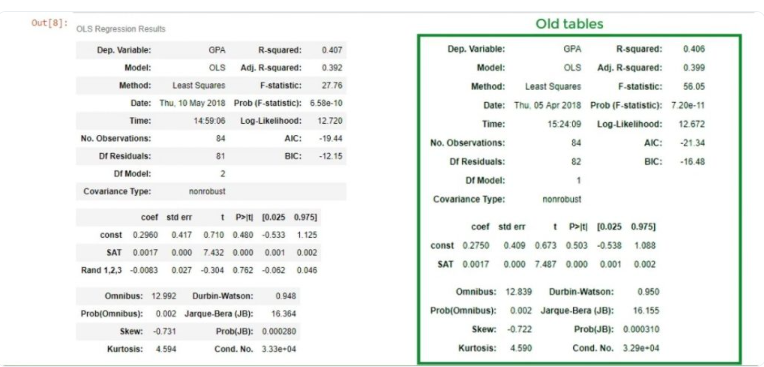

### El nuevo R-cuadrado

Notamos que el nuevo R-cuadrado es 0.407, por lo que parece que hemos aumentado el poder explicativo del modelo. Pero luego nuestro entusiasmo se ve empañado por el R-cuadrado ajustado de 0,392.

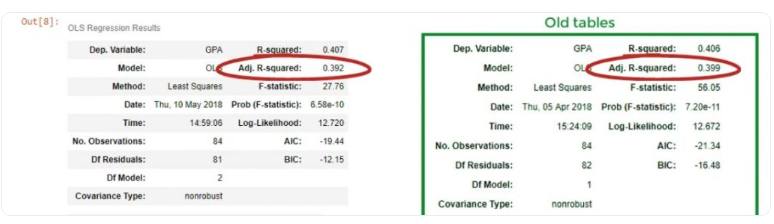

Fuimos penalizados por agregar una variable adicional que no tenía un fuerte poder explicativo. Hemos añadido información pero hemos perdido valor.

### Importante: el punto es que debe elegir cuidadosamente sus datos y excluir la información inútil.

Sin embargo, uno supondría que el análisis de regresión es más inteligente que eso. Agregar una variable poco práctica debe ser señalado por el modelo de alguna manera.

Bien, eso es cierto. Echemos un vistazo a la tabla de coeficientes. Hemos determinado un coeficiente para la variable Rand 1,2,3, ¡pero su valor P es 0,762!

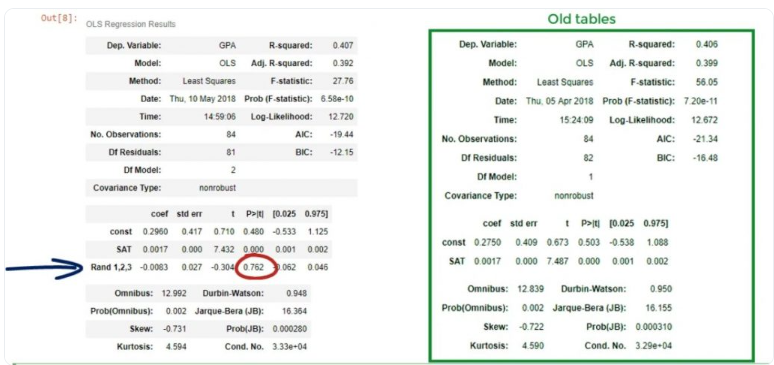

## La hipótesis nula

La hipótesis nula de la prueba es que β = 0. ¡No podemos rechazar la hipótesis nula al 76% de nivel de significancia!

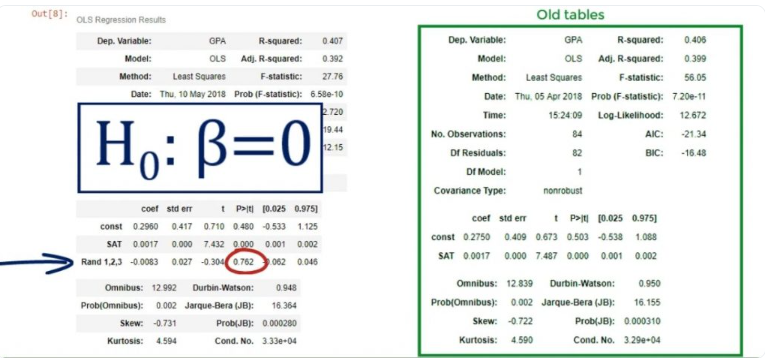

Este es un valor P increíblemente alto.

### Importante: para que un coeficiente sea estadísticamente significativo, generalmente queremos un valor P de menos de 0,05.

Nuestra conclusión es que la variable Rand 1,2,3 no solo empeora el poder explicativo del modelo, reflejado por un R-cuadrado ajustado más bajo, sino que también es insignificante. Por lo tanto, debe descartarse por completo.

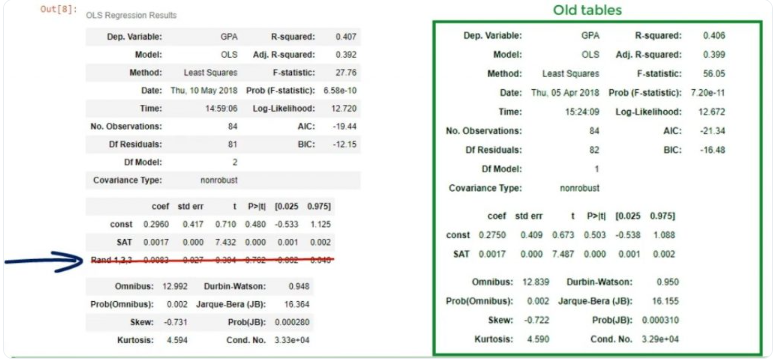

### Descartar variables inútiles

Descartar variables inútiles es importante. Puedes ver el modelo original cambiado de:

ŷ = 0,275 + 0,0017* x1

a

ŷ = 0,296+ 0,0017* x1- 0,0083 * x2

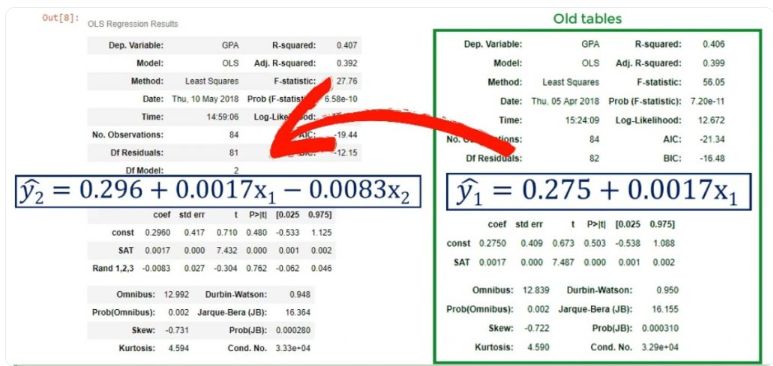

La elección de la tercera variable afectó el intercepto. Siempre que tenga una variable que esté arruinando el modelo, no debe usar este modelo por completo. Esto se debe a que el sesgo de esta variable se refleja en los coeficientes de las demás variables. El enfoque correcto es eliminarlo de la regresión y ejecutar uno nuevo, omitiendo el predictor problemático.

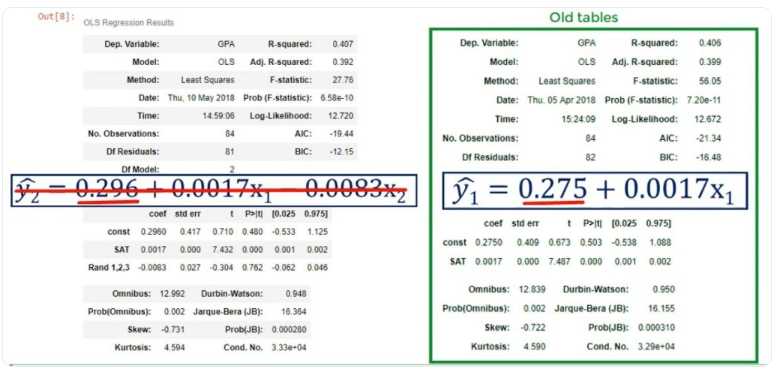

### Sencillez

Hay una consideración más con respecto a la eliminación de variables de un modelo. Podemos agregar 100 variables diferentes a un modelo y probablemente el poder predictivo del modelo sea sobresaliente. Sin embargo, esta estrategia hace que el análisis de regresión sea inútil. Estamos tratando de usar algunas variables independientes que predicen aproximadamente el resultado. La compensación es compleja, pero la simplicidad se recompensa mejor que un mayor poder explicativo.

### ¿Cómo comparar modelos de regresión?

Finalmente, el R-cuadrado ajustado es la base para comparar modelos de regresión. Una vez más, solo tiene sentido comparar dos modelos considerando la misma variable dependiente y utilizando el mismo conjunto de datos. Si comparamos dos modelos que se refieren a dos variables dependientes diferentes, estaremos haciendo una comparación de manzanas con naranjas. Si usamos diferentes conjuntos de datos, es un problema de manzanas a dinosaurios.

Como puede ver, el R-cuadrado ajustado es un paso en la dirección correcta, pero no debe ser la única medida confiable. Se recomienda precaución, mientras que la lógica minuciosa y la diligencia son obligatorias.

### Lo que hemos aprendido

En resumen, el R-cuadrado básicamente nos dice qué parte de la variabilidad de nuestros datos se explica por la línea de regresión. El mejor valor para un R-cuadrado depende del caso particular. Cuando sentimos que nos falta información importante, simplemente podemos agregar más factores. Aquí es donde entra en juego el R-cuadrado ajustado. Mide la variabilidad de nuestro modelo pero también considera el número de variables. Por lo tanto, siempre es menor que el R-cuadrado. Además, el R-cuadrado ajustado es la base para comparar modelos de regresión.

Después de leer esto, probablemente sienta que está listo para profundizar en el campo de las regresiones lineales. Tal vez esté interesado en descubrir cómo estimar una ecuación de regresión lineal. O tal vez quiera saber qué considerar antes de realizar un análisis de regresión.